# Testing the blurryness of keras layers transforms vs keras ImageDataGenerator transforms

Create sample images for sequentially applied keras layers transforms and the corresponding ImageDataGenerator transforms, and compare the results. The blurryness of the keras layers transforms may be due to stacked interpolation between each transform, as opposed to the ImageDataGenerator which applies all transforms in one go, and only performs interpolation once. The blurryness is more noticeable with the RandomZoom layer, which may be due to the fact that it performs a larger transformation than the other layers, and therefore requires more interpolation.

In [6]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# data
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

We will now create a sequential model for each of the three data augmentation techniques (translation, flip, zoom) using keras layers, and apply them sequentially to a sample image from the CIFAR-10 dataset. We will then create a corresponding ImageDataGenerator for each sequence of techniques and compare the two results. We will use the same random seed for both methods to ensure that the same transformations are applied, and we will use the same interpolation method (bilinear) for both methods to ensure a fair comparison. We will also use the same fill mode (nearest) for both methods to ensure that the same strategy is used for filling in pixels outside the boundaries of the input image.

In [7]:
# keras sequential
interpolation_method = 'bilinear' # Use bilinear interpolation for better quality data_aug_GPU_combined = keras.Sequential([ layers.RandomTranslation(0.1, 0.1, fill_mode="nearest", interpolation= interpolation_method, seed = 128), layers.RandomFlip("horizontal", seed = 128), layers.RandomZoom(0.1, fill_mode="nearest", interpolation= interpolation_method,

# rotation layer
keras_layer_rotation = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomRotation(1/36, # Rotate images by up to 10 degrees (1/36 of a full rotation)
                          fill_mode="nearest",
                          interpolation= interpolation_method,
                          seed = 128)
    ])

# translation layer
keras_layer_translation = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomTranslation(0.1,
                             0.1,
                             fill_mode="nearest",
                             interpolation= interpolation_method,
                             seed = 128)
    ])

# flip layer
keras_layer_flip = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal",
                      seed = 128)
    ])

# zoom layer
keras_layer_zoom = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomZoom(0.1,
                      fill_mode="nearest",
                      interpolation= interpolation_method,
                      seed = 128)
    ])

# CPU augmentation using ImageDataGenerator

# rotation
data_aug_CPU_rotation = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,            # Rotate images by up to 15 degrees
    fill_mode='nearest',         # Fill strategy for pixels outside boundaries
    interpolation_order=1,       # Use bilinear interpolation (order=1) for better quality
)

# rotation + translation
data_aug_CPU_rotation_translation = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,            # Rotate images by up to 15 degrees
    width_shift_range=0.1,       # Horizontal shifts up to 10%
    height_shift_range=0.1,      # Vertical shifts up to 10%
    fill_mode='nearest',         # Fill strategy for pixels outside boundaries
    interpolation_order=1,       # Use bilinear interpolation (order=1) for better quality
)

# rotation + translation + flip
data_aug_CPU_rotation_translation_flip = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,            # Rotate images by up to 15 degrees
    width_shift_range=0.1,       # Horizontal shifts up to 10%
    height_shift_range=0.1,      # Vertical shifts up to 10%
    horizontal_flip=True,        # Random horizontal flips
    fill_mode='nearest',         # Fill strategy for pixels outside boundaries
    interpolation_order=1,       # Use bilinear interpolation (order=1) for better quality
)

# rotation + translation + flip + zoom
data_aug_CPU_rotation_translation_flip_zoom = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,            # Rotate images by up to 15 degrees
    width_shift_range=0.1,       # Horizontal shifts up to 10%
    height_shift_range=0.1,      # Vertical shifts up to 10%
    horizontal_flip=True,        # Random horizontal flips
    zoom_range=0.1,              # Random zoom up to 10%
    fill_mode='nearest',         # Fill strategy for pixels outside boundaries
    interpolation_order=1,       # Use bilinear interpolation (order=1) for better quality
)



I0000 00:00:1770903684.655997     874 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9500 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Now we can select 2 images and apply sequentially the 4 augmentation techniques (rotation, translation, flip, zoom) using keras layers, and then apply the same techniques using ImageDataGenerator, and compare the results. We will use a seed of 128 during all comparisons and bilinear interpolation for all transformations, as well as nearest fill mode for all transformations.

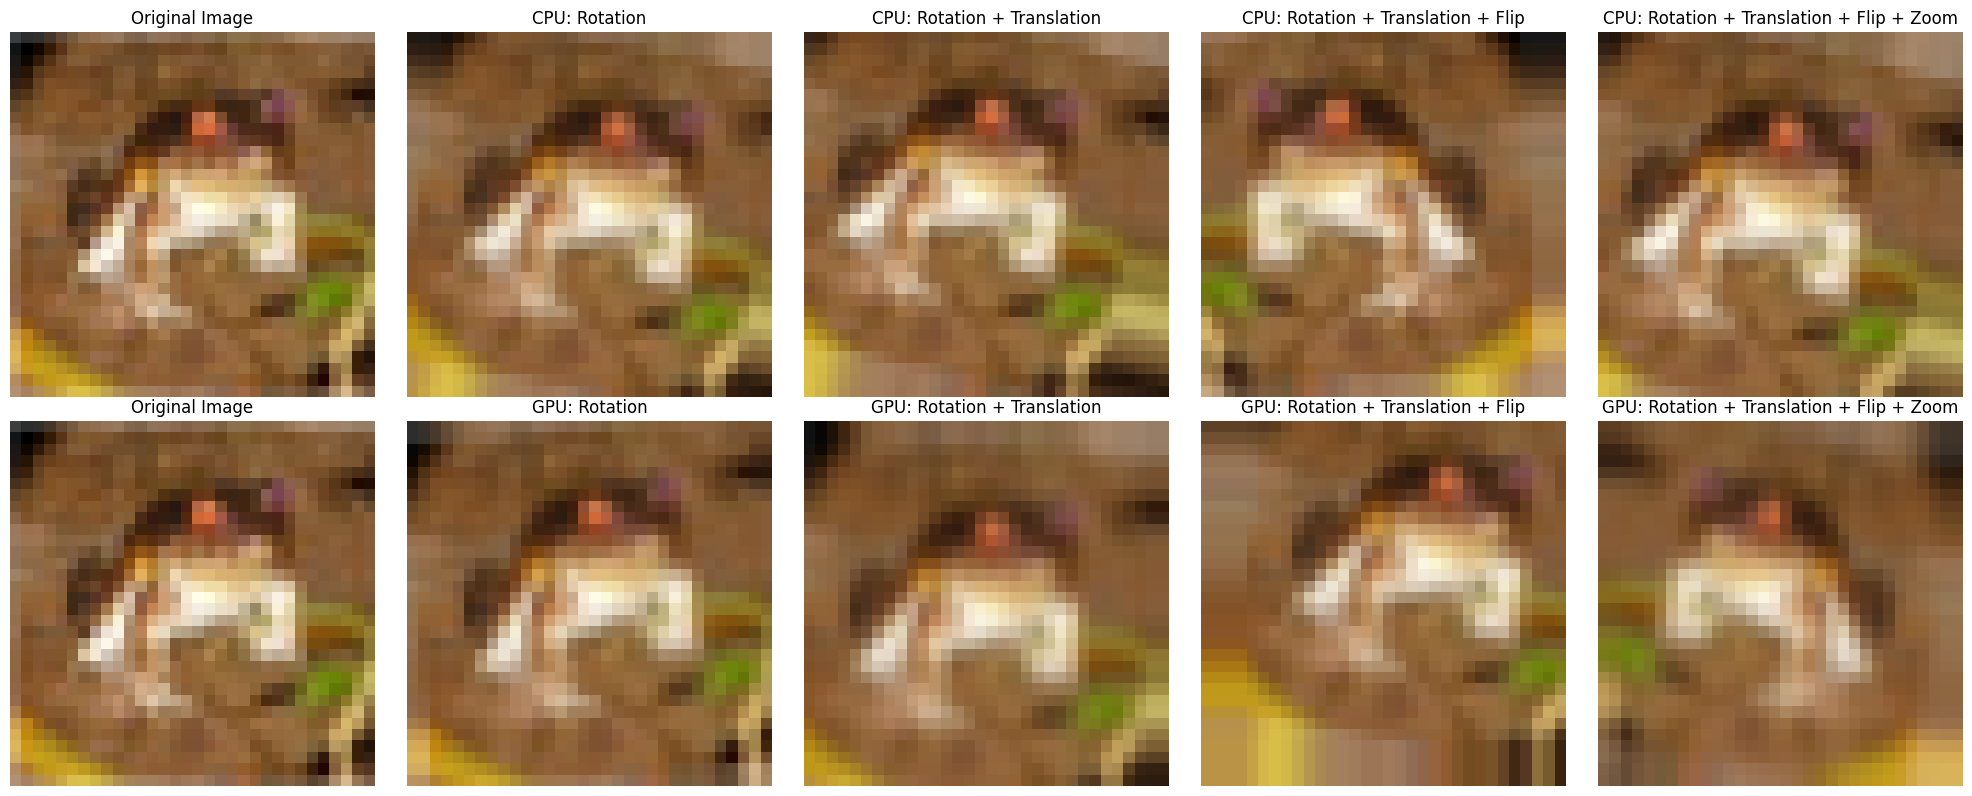

In [8]:
# plot: 2x5 grid, of origional, rotation, rotation + translation, rotation + translation + flip, rotation + translation + flip + zoom
# first row: CPU augmentation
# second row: GPU augmentation

# select image
image_index = 0 
original_image = x_train[image_index]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
# first row: CPU augmentation 
axes[0, 0].imshow(original_image) 
axes[0, 0].set_title("Original Image") 
axes[0, 0].axis('off')

# rotation
augmented_image_rotation = data_aug_CPU_rotation.random_transform(original_image) 
axes[0, 1].imshow(augmented_image_rotation) 
axes[0, 1].set_title("CPU: Rotation") 
axes[0, 1].axis('off')

# rotation + translation
augmented_image_rotation_translation = data_aug_CPU_rotation_translation.random_transform(original_image) 
axes[0, 2].imshow(augmented_image_rotation_translation) 
axes[0, 2].set_title("CPU: Rotation + Translation") 
axes[0, 2].axis('off')

# rotation + translation + flip
augmented_image_rotation_translation_flip = data_aug_CPU_rotation_translation_flip.random_transform(original_image) 
axes[0, 3].imshow(augmented_image_rotation_translation_flip) 
axes[0, 3].set_title("CPU: Rotation + Translation + Flip") 
axes[0, 3].axis('off')

# rotation + translation + flip + zoom
augmented_image_rotation_translation_flip_zoom = data_aug_CPU_rotation_translation_flip_zoom.random_transform(original_image) 
axes[0, 4].imshow(augmented_image_rotation_translation_flip_zoom) 
axes[0, 4].set_title("CPU: Rotation + Translation + Flip + Zoom") 
axes[0, 4].axis('off')



# second row: GPU augmentation

# original image
axes[1, 0].imshow(original_image) 
axes[1, 0].set_title("Original Image") 
axes[1, 0].axis('off')

# expand image dims
original_image = np.expand_dims(original_image, axis=0)

# rotation
augmented_image_rotation_gpu = keras_layer_rotation(original_image) 
axes[1, 1].imshow(augmented_image_rotation_gpu[0].numpy().astype(np.uint8)) 
axes[1, 1].set_title("GPU: Rotation") 
axes[1, 1].axis('off')

# rotation + translation
augmented_image_rotation_translation_gpu = keras_layer_translation(keras_layer_rotation(original_image)) 
axes[1, 2].imshow(augmented_image_rotation_translation_gpu[0].numpy().astype(np.uint8)) 
axes[1, 2].set_title("GPU: Rotation + Translation") 
axes[1, 2].axis('off')

# rotation + translation + flip
augmented_image_rotation_translation_flip_gpu = keras_layer_flip(keras_layer_translation(keras_layer_rotation(original_image))) 
axes[1, 3].imshow(augmented_image_rotation_translation_flip_gpu[0].numpy().astype(np.uint8)) 
axes[1, 3].set_title("GPU: Rotation + Translation + Flip") 
axes[1, 3].axis('off')

# rotation + translation + flip + zoom
augmented_image_rotation_translation_flip_zoom_gpu = keras_layer_zoom(keras_layer_flip(keras_layer_translation(keras_layer_rotation(original_image)))) 
axes[1, 4].imshow(augmented_image_rotation_translation_flip_zoom_gpu[0].numpy().astype(np.uint8)) 
axes[1, 4].set_title("GPU: Rotation + Translation + Flip + Zoom") 
axes[1, 4].axis('off')

plt.tight_layout()


In [9]:
# function to apply n random augmentations sequentially to an image
def apply_random_augmentations(image, n):

    # Add batch dimension
    augmented_image = np.expand_dims(image, axis=0)
    for _ in range(n):
        augmented_image = keras_layer_zoom(keras_layer_flip(keras_layer_translation(keras_layer_rotation(augmented_image)))) 

    return augmented_image[0].numpy().astype(np.uint8)

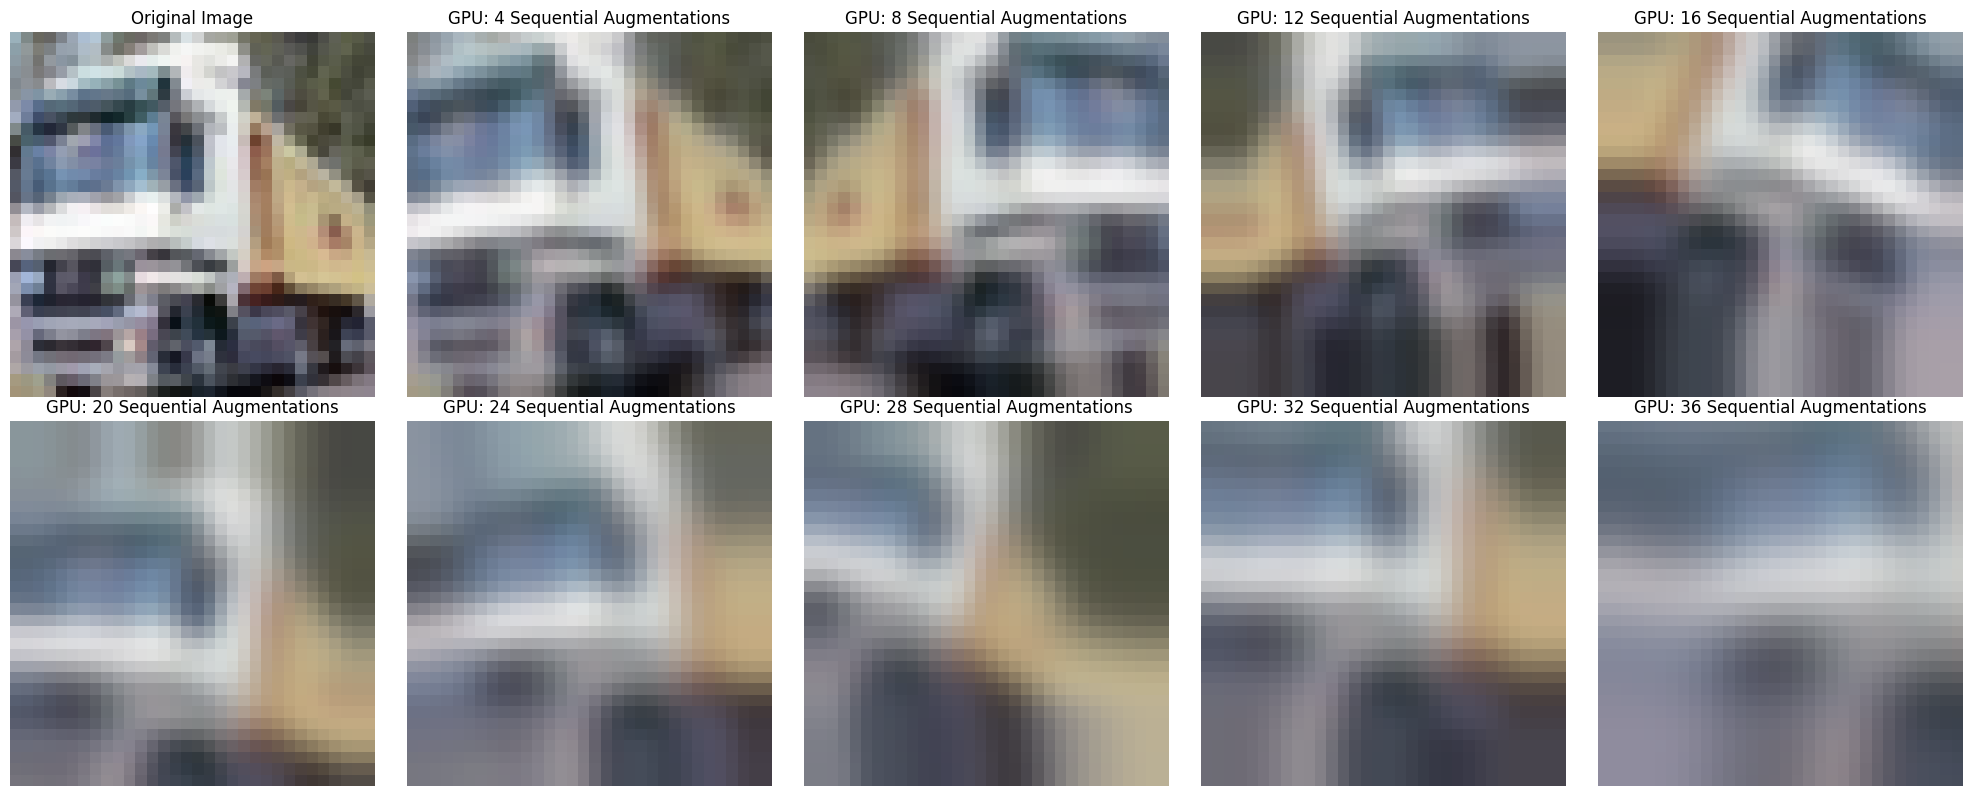

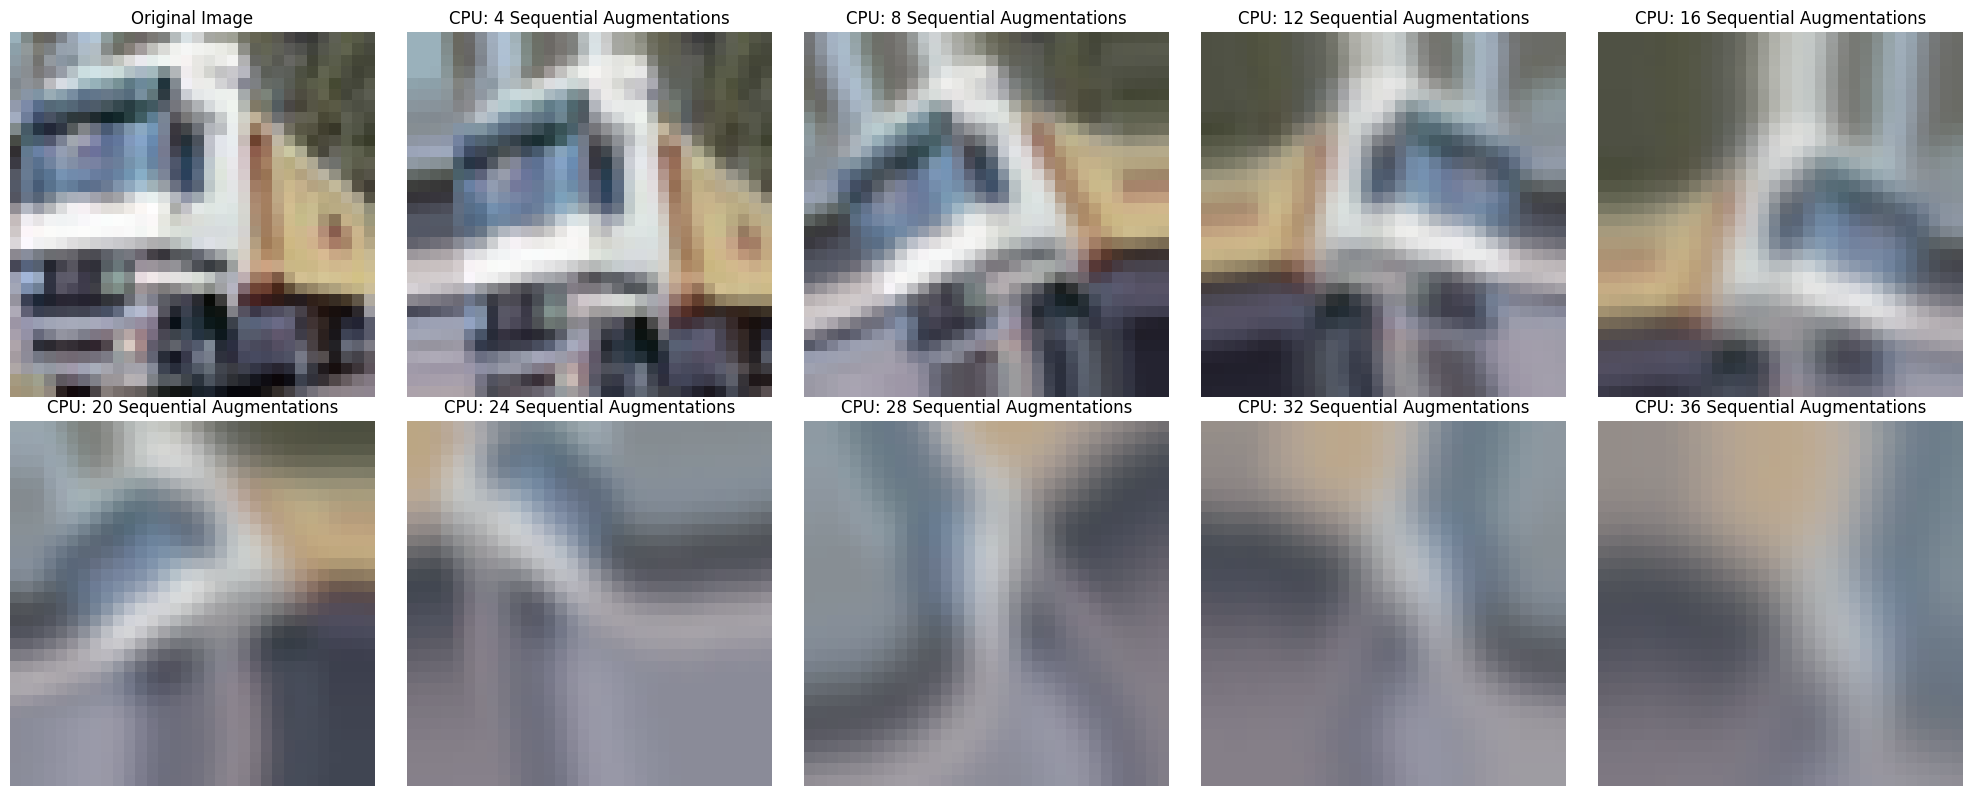

In [14]:
import matplotlib.pyplot as plt

# plot of 2x5 showing sequential applications of augmentattions using keras layers
fig , axes = plt.subplots(2, 5, figsize=(20, 8))

original_image = x_train[1]

# original image
axes[0, 0].imshow(original_image)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')


# add dimension
original_image = original_image[np.newaxis, ...]

# loop through and apply augmentations sequentially, plotting each one
for i in range(1,10):
    augmented_image = apply_random_augmentations(original_image[0], i)

    axes[i//5, i%5].imshow(augmented_image) 
    axes[i//5, i%5].set_title(f"GPU: {i*4} Sequential Augmentations") 
    axes[i//5, i%5].axis('off') 
plt.tight_layout()


# same for CPU using data_aug_CPU_rotation_translation_flip_zoom

# plot of 2x5 showing sequential applications of augmentattions using CPU data generator
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

original_image = x_train[1]

# original image
axes[0, 0].imshow(original_image) 
axes[0, 0].set_title("Original Image") 
axes[0, 0].axis('off')


augmented_image = original_image

# loop through and apply augmentations sequentially, plotting each one
for i in range(1,10):
    for _ in range(i):
        augmented_image = data_aug_CPU_rotation_translation_flip_zoom.random_transform(augmented_image)
    axes[i//5, i%5].imshow(augmented_image)
    axes[i//5, i%5].set_title(f"CPU: {i*4} Sequential Augmentations")
    axes[i//5, i%5].axis('off')
plt.tight_layout()



It can be clearly seen that the GPU-accelerated keras layers produce blurrier images than the CPU-bound ImageDataGenerator, which is likely due to the fact that the GPU method performs interpolation between each transform, whereas the CPU method applies all transforms in one go and only performs interpolation once. This distortion destroys high-frequency features in the images, which are crucial if we want top accuracy. The layers method provides model portability, efficient GPU acceleration, and ease of use, which is why it is the industry standard for data augmentation, but on small images like CIFAR-10 (32x32), the distortion effects are too severe and the CPU method provides much better results, despite the potential bottleneck. For larger images, the distortion effects may be less severe, and the GPU method may provide better results due to the improved performance.